# 02 — Sales trends and revenue analysis dashboard (PowerBI)

Monthly revenue, order volume, average order value, seasonality.

**Show monthly sales trend, customer segmentation** The dataset shows growth in online sales. The dashboard will provide charts for sales growth across different regions, customer concentration and top products/categories.



In [1]:
import os

import pandas as pd
import numpy as np

# from dotenv import load_dotenv
# from sqlalchemy import create_engine

# load_dotenv("../.env")

# # Marts only. The dialect keeps the warehouse swappable (§9).
# engine = create_engine(f"bigquery://{os.environ['GCP_PROJECT']}/olist_marts")
data_path=[]

for dirname, _, filenames in os.walk('../data/staging/'):
    for filename in filenames:
       data_path.append(os.path.join(dirname, filename))


data_path

['../data/staging/olist_sellers_dataset.csv',
 '../data/staging/product_category_name_translation.csv',
 '../data/staging/olist_orders_dataset.csv',
 '../data/staging/olist_order_items_dataset.csv',
 '../data/staging/olist_customers_dataset.csv',
 '../data/staging/olist_geolocation_dataset.csv',
 '../data/staging/olist_order_payments_dataset.csv',
 '../data/staging/olist_order_reviews_dataset.csv',
 '../data/staging/olist_products_dataset.csv']

In [2]:
base_path = "../data/staging/"

orders = pd.read_csv(base_path + "olist_orders_dataset.csv")
order_items = pd.read_csv(base_path + "olist_order_items_dataset.csv")
customers = pd.read_csv(base_path + "olist_customers_dataset.csv")
products = pd.read_csv(base_path + "olist_products_dataset.csv")
categories = pd.read_csv(base_path + "product_category_name_translation.csv")
order_payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(base_path + "olist_order_reviews_dataset.csv")



In [3]:
order_items.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [4]:
customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [5]:
products.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


In [6]:
from google.cloud import bigquery

# Define target BigQuery details
project_id = "dsai6mod2"
dataset_id = "dsdwh"
table_id = "sales_fact"

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

orders['org_to_carrier_time'] = orders['order_delivered_carrier_date'] - orders['order_approved_at']
orders['carrier_to_customer_time'] = orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']
orders['actual_arrival_time'] = orders['order_delivered_customer_date'] - orders['order_approved_at']
orders['apply_SLA'] = orders['order_delivered_customer_date'] <= orders['order_estimated_delivery_date']
orders['delivery_delay']= orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']

orders_sla = orders[orders['apply_SLA'] == True]

order_items=pd.merge(orders_sla,order_items,on='order_id')

#orders_customers = pd.merge(order_items,customers, on='customer_id',how='outer')
final_data = pd.merge(order_items,products,on='product_id')

final_data["order_purchase_timestamp"]=pd.to_datetime(final_data["order_purchase_timestamp"])
final_data['month']=final_data["order_purchase_timestamp"].dt.month
final_data['year']=final_data["order_purchase_timestamp"].dt.year

# Option 1: Using pandas-gbq
# Guarded: this replaces the shared BigQuery table, so it only runs on request.
if os.getenv("LOAD_TO_BQ") == "1":
    final_data.to_gbq(
        destination_table=f"{dataset_id}.{table_id}",
        project_id=project_id,
        if_exists="replace"  # options: 'fail', 'replace', 'append'
    )
    print("DataFrame loaded successfully into BigQuery!")
else:
    print("Skipping BigQuery load (set LOAD_TO_BQ=1 to enable).")


Skipping BigQuery load (set LOAD_TO_BQ=1 to enable).


In [7]:
order_items["order_purchase_timestamp"]=pd.to_datetime(order_items["order_purchase_timestamp"])
order_items['month']=order_items["order_purchase_timestamp"].dt.month
order_items['year']=order_items["order_purchase_timestamp"].dt.year

year
2016      40604.33
2017    5512145.79
2018    6509194.49
Name: price, dtype: float64


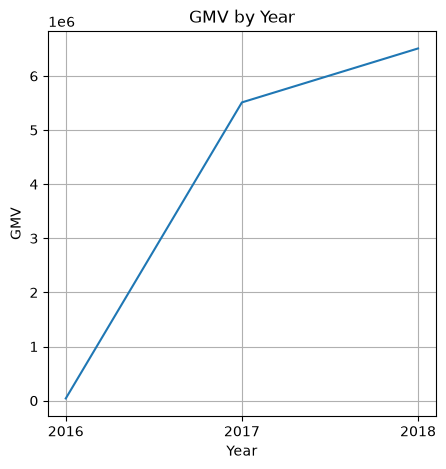

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

gmv=order_items.groupby('year')['price'].sum()
print(gmv)
plt.figure(figsize=(5,5))
plt.plot(gmv.index,gmv.values)
plt.title("GMV by Year")
plt.xlabel("Year")
plt.ylabel("GMV")
plt.grid(True)
plt.xticks(gmv.index)
plt.show()

In [9]:
# from google.cloud import bigquery

# client = bigquery.Client()


# # Example DataFrame
# df = pd.DataFrame({
#     "customer_id": [1, 2, 3],
#     "customer_name": ["Alice", "Bob", "Charlie"],
#     "spend": [100.5, 200.75, 300.0]
# })

# # Define target BigQuery details
# project_id = "dsai6mod2"
# dataset_id = "dsdwh"
# table_id = "sales_trends"

# # Option 1: Using pandas-gbq
# df.to_gbq(
#     destination_table=f"{dataset_id}.{table_id}",
#     project_id=project_id,
#     if_exists="replace"  # options: 'fail', 'replace', 'append'
# )


# print("DataFrame loaded successfully into BigQuery!")
